# Viscoelastic earthquake cycle model

This notebook compares VECycle interseismic Green’s functions with homogeneous Green’s functions. Because VECycle has a native geometry builder, the homogeneous reference is built on the actual interface returned by VECycle so that the two inversions use the same source geometry.

![Interface Geometry](./images/cycle_interface.png)

In [7]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import geoslip2d as gs2d


cwd = Path.cwd().resolve()
if (cwd / "src" / "geoslip2d").is_dir():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parent

OUTPUT_DIR = PROJECT_ROOT / "Geodesy_TSC" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"OUTPUT_DIR   = {OUTPUT_DIR}")



PROJECT_ROOT = /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D
OUTPUT_DIR   = /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D/Geodesy_TSC/outputs


In [8]:
from geoslip2d.notebook_helpers import (
    make_synthetic_observations,
    patch_center_depths,
    patch_center_x,
    plot_inversion_results,
    plot_surface_velocities,
    run_pair_inversions,
    surface_velocity,
    uniform_backslip_above_depth,
)

## 1. Requested geometry parameters and observation grid

The VECycle solver has a native geometry builder. This notebook passes matching geometry parameters to VECycle, then builds the homogeneous reference on the actual interface returned by VECycle so the forward and inverse comparisons use the same source geometry.

InterfaceGeometry(n_patch=40, x=[0, 305] km, z=[-0, 83.4] km)


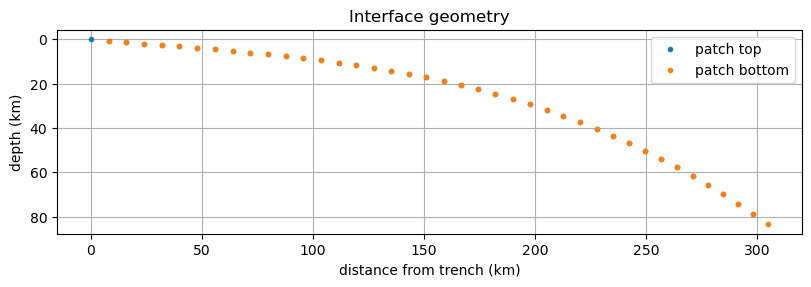

In [9]:
faultdip_trench = 5.0
faultdip_bottom = 35.0
x_trench = 0.0
x_bottom = 300.0
z_bottom = 80.0
patch_length = 8.0

xobs = np.linspace(20, 500.0, 300)
locking_depth_km = 40.0
backslip_rate = 1.0

# Fallback/shared geometry for plotting and for passing requested geometry parameters.
requested_interface = gs2d.make_interface_geometry_legacy(
    faultdip_trench=faultdip_trench,
    x_trench=x_trench,
    x_bottom=x_bottom,
    faultdip_bottom=faultdip_bottom,
    z_bottom=z_bottom,
    patch_length=patch_length,
)
print(requested_interface.summary())
fig = gs2d.plot_interface(requested_interface)
plt.show()

## 2. Build homogeneous and vecycle Green's functions

In [ ]:
# Build native VECycle Green's functions with requested geometry overrides.
# VECycle uses its own native geometry internally, so after building we use the
# returned VECycle interface as the comparison geometry.
vecycle_cfg = gs2d.VECycleConfig(
    mode="build",
    component="interseismic",
    progress=True,
    output_sign=-1.0,
    config_overrides={
        "geometry.faultdip_trench": faultdip_trench,
        "geometry.faultdip_bottom": faultdip_bottom,
        "geometry.x_trench": x_trench,
        "geometry.x_bottom": x_bottom,
        "geometry.wedge_bot": z_bottom,
        "geometry.pL": patch_length,
        "geometry.wedge_top_x": 300.0,
        "geometry.L_slab": 500.0,
    },
)

greens_nonhom = gs2d.build_greens(
    "vecycle",
    requested_interface,
    xobs,
    vecycle_cfg,
)

# Build homogeneous Green's functions on the actual VECycle interface so both
# inversions use the same source geometry.
interface = greens_nonhom.interface
print("Actual VECycle comparison interface:")
print(interface.summary())

greens_hom = gs2d.build_greens(
    "homogeneous",
    interface,
    xobs,
    length_override=None,
    progress=True,
    output_sign=-1.0,
)

Building raw Green's-function blocks...
Source 1/11 code='1': 207 of 207 patches
Source 2/11 code='2': 200 of 200 patches
Source 3/11 code='3': 5 of 5 patches
Source 4/11 code='4': 5 of 5 patches
Source 5/11 code='5': 4 of 4 patches
Source 6/11 code='6': 238 of 238 patches
Source 7/11 code='7': 200 of 200 patches
Source 8/11 code='8': 250 of 250 patches
Source 9/11 code='b': 99 of 99 patches
Source 10/11 code='t': 62 of 62 patches
Source 11/11 code='i': 40 of 40 patches
Compiling linear-system matrices...
Cycle source 1 of 40
Cycle source 2 of 40
Cycle source 3 of 40
Cycle source 4 of 40
Cycle source 5 of 40
Cycle source 6 of 40
Cycle source 7 of 40
Cycle source 8 of 40
Cycle source 9 of 40
Cycle source 10 of 40
Cycle source 11 of 40
Cycle source 12 of 40
Cycle source 13 of 40
Cycle source 14 of 40
Cycle source 15 of 40
Cycle source 16 of 40
Cycle source 17 of 40
Cycle source 18 of 40
Cycle source 19 of 40
Cycle source 20 of 40
Cycle source 21 of 40
Cycle source 22 of 40
Cycle source 2

## 3. Forward model uniform backslip above the locking depth

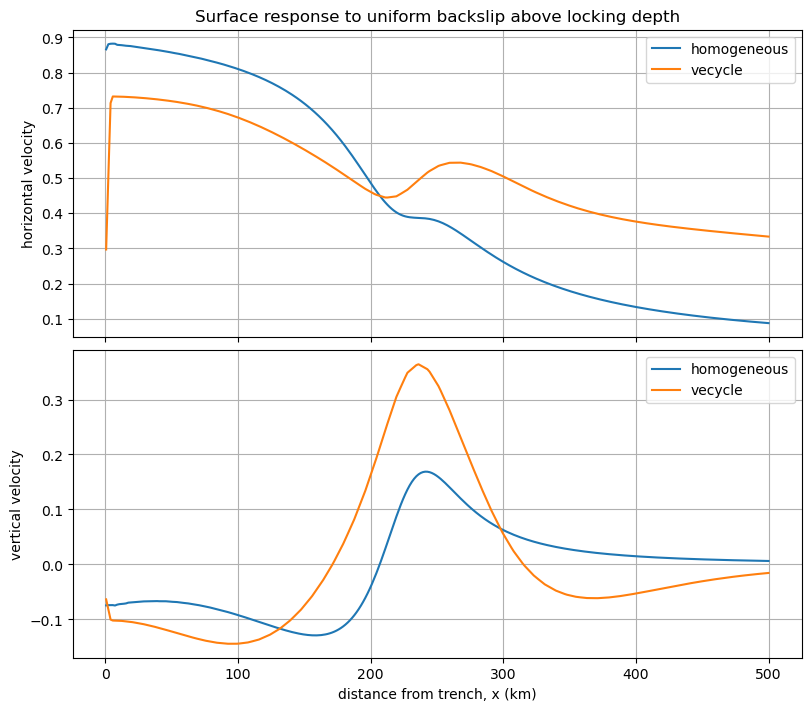

In [ ]:
slip_hom = uniform_backslip_above_depth(greens_hom, locking_depth_km, backslip_rate)
slip_nonhom = uniform_backslip_above_depth(greens_nonhom, locking_depth_km, backslip_rate)

vel_hom = surface_velocity(greens_hom, slip_hom)
vel_nonhom = surface_velocity(greens_nonhom, slip_nonhom)

fig = plot_surface_velocities(xobs, vel_hom, vel_nonhom, "vecycle")
plt.show()

## 4. Synthetic inversion

The synthetic data are generated with the **vecycle** Green's functions using the same uniform-backslip model. The same synthetic horizontal and vertical velocities are then inverted twice: once with homogeneous Green's functions and once with vecycle Green's functions.

In [ ]:
truth_slip = slip_nonhom.copy()
observations = make_synthetic_observations(
    greens_nonhom,
    truth_slip,
    sigma_h=0.02,
    sigma_v=0.02,
    noise=False,
)

out_hom, out_nonhom = run_pair_inversions(
    observations,
    greens_hom,
    greens_nonhom,
    alpha=0.5,
)

fig = plot_inversion_results(
    greens_hom,
    greens_nonhom,
    truth_slip,
    out_hom,
    out_nonhom,
    "vecycle",
)
plt.show()